# 04 - Is aligned

In [15]:

import pandas as pd
from os.path import expanduser, join, getmtime, isfile
from glob import glob
from eogtouch.models.enums import StimuliColor
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (20,6)

df = pd.read_parquet("/Users/Ana/20250507_132315.parquet")

## Rutinas

In [16]:

# Identificar cuándo empieza una fijación (de blanco a azul o verde)
df["prev_color"] = df["stimuli_color"].shift(1)

df["start_fixation"] = (
    (df["prev_color"] == StimuliColor.White.int_value) &
    (df["stimuli_color"].isin([StimuliColor.Green.int_value, StimuliColor.Blue.int_value]))
)

# Identificar cuándo termina una fijación (cuando vuelve a blanco)
df["end_fixation"] = (
    (df["prev_color"].isin([StimuliColor.Green.int_value, StimuliColor.Blue.int_value]) &
    (df["stimuli_color"] == StimuliColor.White.int_value)
    )
)

# Obtener los timestamps de inicio y fin
start_times = df[df["start_fixation"]]["timestamp"].reset_index(drop=True)
end_times = df[df["end_fixation"]]["timestamp"].reset_index(drop=True)

# Asegurarse de que hay pares completos --> evita restar arrays de diferente tamaño 
# o que solo haya inicio porque el usuario cierra antes el programa

min_len = min(len(start_times), len(end_times))
duraciones = end_times[:min_len] - start_times[:min_len]

# Crear DataFrame con resultados
df_resultados = pd.DataFrame({
    "start_time": start_times[:min_len],
    "end_time": end_times[:min_len],
    "fixation_duration_ms": duraciones
})


## Alineación en el tiempo

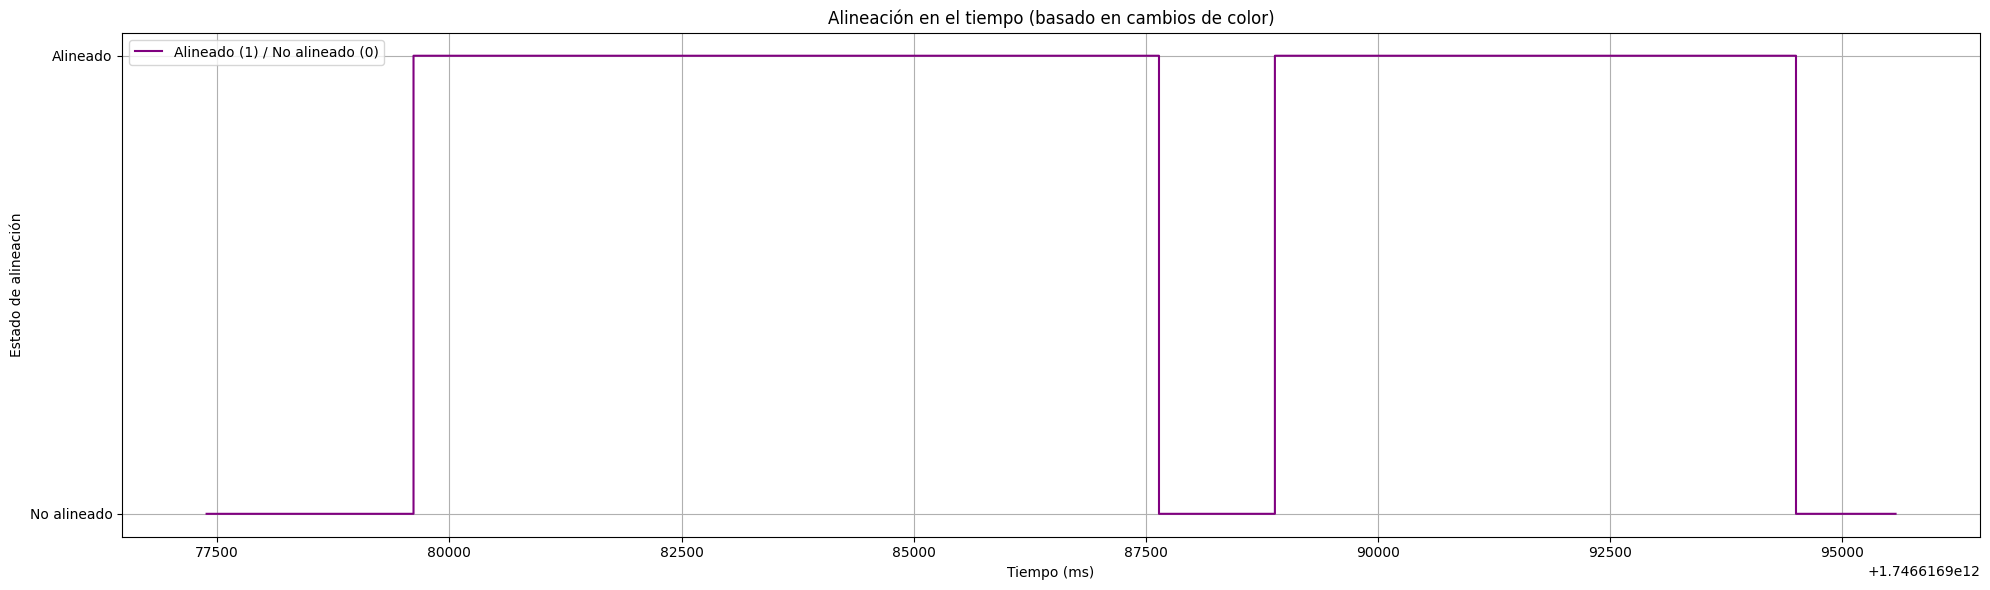

In [17]:
# Inicializar la columna
df["is_aligned"] = False

# Obtener los índices de inicio y fin de cada alineación
start_idx = df.index[df["start_fixation"]].tolist()
end_idx = df.index[df["end_fixation"]].tolist()

# Asegurar que los pares están completos
min_len = min(len(start_idx), len(end_idx))
start_idx = start_idx[:min_len]
end_idx = end_idx[:min_len]

# Rellenar is_aligned = True entre cada par de inicio-fin
for start, end in zip(start_idx, end_idx):
    df.loc[start:end, "is_aligned"] = True



plt.plot(df["timestamp"], df["is_aligned"].astype(int), label="Alineado (1) / No alineado (0)", drawstyle="steps-post", color="purple")
plt.title("Alineación en el tiempo (basado en cambios de color)")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Estado de alineación")
plt.yticks([0, 1], ["No alineado", "Alineado"])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Alineación y color a lo largo del tiempo

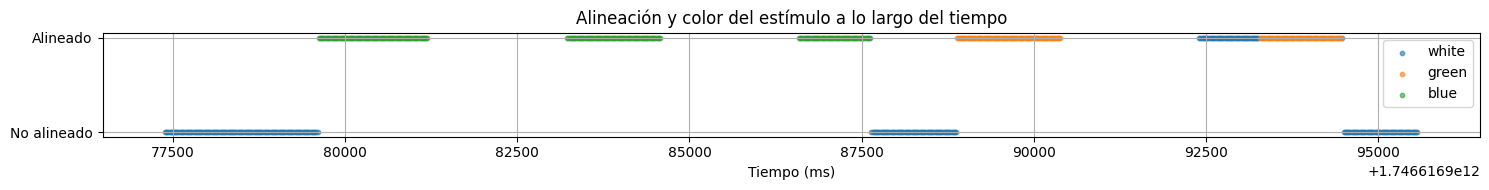

In [18]:
# Colores simplificados
color_map = {
    StimuliColor.White.int_value: "white",
    StimuliColor.Green.int_value: "green",
    StimuliColor.Blue.int_value: "blue"
}

df["color_name"] = df["stimuli_color"].map(color_map)

plt.figure(figsize=(15, 2))

# Usamos scatter para cada punto en el tiempo, codificado por color y alineación
for color in ["white", "green", "blue"]:
    subset = df[df["color_name"] == color]
    plt.scatter(subset["timestamp"], 
                subset["is_aligned"].astype(int), 
                label=color, 
                s=10, alpha=0.6)

plt.yticks([0, 1], ["No alineado", "Alineado"])
plt.title("Alineación y color del estímulo a lo largo del tiempo")
plt.xlabel("Tiempo (ms)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
